# 📚 Student Performance Prediction
## Notebook 1 — Data Cleaning & Exploratory Data Analysis
**Target Variable:** `exam_score` (Regression)

**Pipeline Steps:**
1. Load & inspect data
2. Drop unnecessary columns
3. Handle missing values
4. Encode categoricals
5. Correlation analysis
6. Save cleaned data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('student_habits_performance.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 1. Drop Unnecessary Columns

In [3]:
# Drop student_id (unique identifier) and netflix_hours (not predictive)
DROP_COLS = ['student_id', 'netflix_hours']
df.drop(columns=DROP_COLS, inplace=True)
print('Remaining columns:', list(df.columns))
print(f'Shape after drop: {df.shape}')

Remaining columns: ['age', 'gender', 'study_hours_per_day', 'social_media_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']
Shape after drop: (1000, 14)


## 2. Missing Value Analysis

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

# parental_education_level has 91 nulls (~9%) — fill with mode
mode_val = df['parental_education_level'].mode()[0]
df['parental_education_level'].fillna(mode_val, inplace=True)
print(f'\nFilled parental_education_level nulls with mode: "{mode_val}"')
print('Remaining nulls:', df.isnull().sum().sum())

                          Missing Count  Missing %
parental_education_level             91        9.1

Filled parental_education_level nulls with mode: "High School"
Remaining nulls: 0


## 3. Data Types & Basic Stats

In [5]:
print('--- Dtypes ---')
print(df.dtypes)
print('\n--- Numerical Summary ---')
df.describe().round(2)

--- Dtypes ---
age                                int64
gender                            object
study_hours_per_day              float64
social_media_hours               float64
part_time_job                     object
attendance_percentage            float64
sleep_hours                      float64
diet_quality                      object
exercise_frequency                 int64
parental_education_level          object
internet_quality                  object
mental_health_rating               int64
extracurricular_participation     object
exam_score                       float64
dtype: object

--- Numerical Summary ---


,age,study_hours_per_day,social_media_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.50,3.55,2.51,84.13,6.47,3.04,5.44,69.60
std,2.31,1.47,1.17,9.40,1.23,2.03,2.85,16.89
min,17.00,0.00,0.00,56.00,3.20,0.00,1.00,18.40
25%,18.75,2.60,1.70,78.00,5.60,1.00,3.00,58.48
50%,20.00,3.50,2.50,84.40,6.50,3.00,5.00,70.50
75%,23.00,4.50,3.30,91.02,7.30,5.00,8.00,81.32
max,24.00,8.30,7.20,100.00,10.00,6.00,10.00,100.00


## 4. Target Variable Distribution

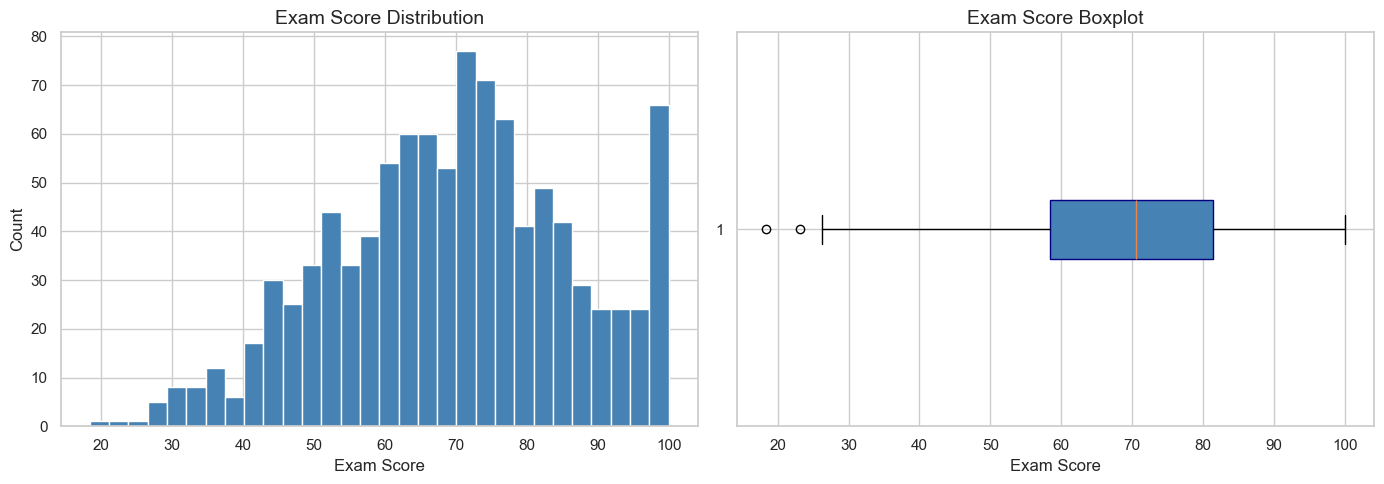

Mean: 69.60 | Std: 16.89


In [7]:
import os

os.makedirs("plots", exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['exam_score'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Exam Score Distribution', fontsize=14)
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['exam_score'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Exam Score Boxplot', fontsize=14)
axes[1].set_xlabel('Exam Score')

plt.tight_layout()
plt.savefig('plots/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean: {df["exam_score"].mean():.2f} | Std: {df["exam_score"].std():.2f}')

## 5. Categorical Feature Distributions

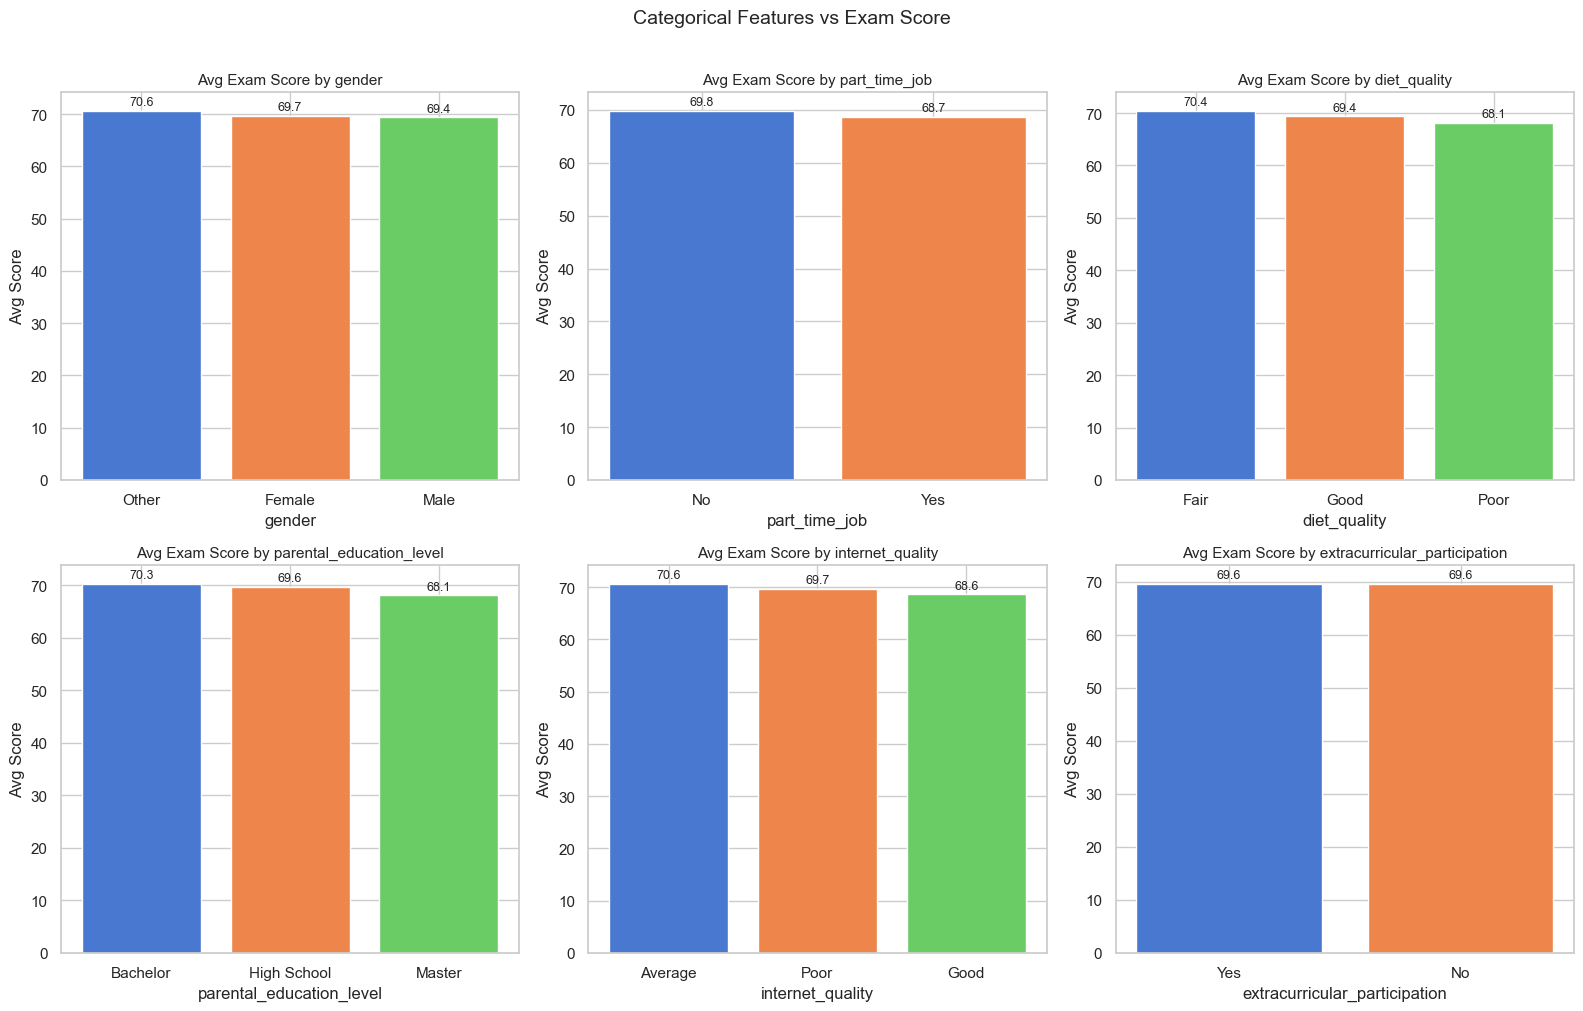

In [8]:
import os
os.makedirs('plots', exist_ok=True)

cat_cols = ['gender', 'part_time_job', 'diet_quality',
            'parental_education_level', 'internet_quality', 'extracurricular_participation']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df.groupby(col)['exam_score'].mean().sort_values(ascending=False).index
    means = df.groupby(col)['exam_score'].mean().reindex(order)
    bars = axes[i].bar(order, means, color=sns.color_palette('muted', len(order)))
    axes[i].set_title(f'Avg Exam Score by {col}', fontsize=11)
    axes[i].set_ylabel('Avg Score')
    axes[i].set_xlabel(col)
    for bar, val in zip(bars, means):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Categorical Features vs Exam Score', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/02_categorical_vs_score.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Encode Categorical Features

In [9]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Binary Yes/No columns
binary_map = {'Yes': 1, 'No': 0}
df_encoded['part_time_job'] = df_encoded['part_time_job'].map(binary_map)
df_encoded['extracurricular_participation'] = df_encoded['extracurricular_participation'].map(binary_map)

# Ordinal encoding for ordered categories
diet_map = {'Poor': 0, 'Fair': 1, 'Good': 2}
internet_map = {'Poor': 0, 'Average': 1, 'Good': 2}
edu_map = {'High School': 0, 'Bachelor': 1, 'Master': 2}

df_encoded['diet_quality'] = df_encoded['diet_quality'].map(diet_map)
df_encoded['internet_quality'] = df_encoded['internet_quality'].map(internet_map)
df_encoded['parental_education_level'] = df_encoded['parental_education_level'].map(edu_map)

# Label encode gender (Male/Female/Other)
le = LabelEncoder()
df_encoded['gender'] = le.fit_transform(df_encoded['gender'])

print('Encoded dtypes:')
print(df_encoded.dtypes)
df_encoded.head(3)

Encoded dtypes:
age                                int64
gender                             int32
study_hours_per_day              float64
social_media_hours               float64
part_time_job                      int64
attendance_percentage            float64
sleep_hours                      float64
diet_quality                       int64
exercise_frequency                 int64
parental_education_level           int64
internet_quality                   int64
mental_health_rating               int64
extracurricular_participation      int64
exam_score                       float64
dtype: object


,age,gender,study_hours_per_day,social_media_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,0,0.0,1.2,0,85.0,8.0,1,6,2,1,8,1,56.2
1,20,0,6.9,2.8,0,97.3,4.6,2,6,0,1,8,0,100.0
2,21,1,1.4,3.1,0,94.8,8.0,0,1,0,0,1,0,34.3


## 7. Correlation Analysis

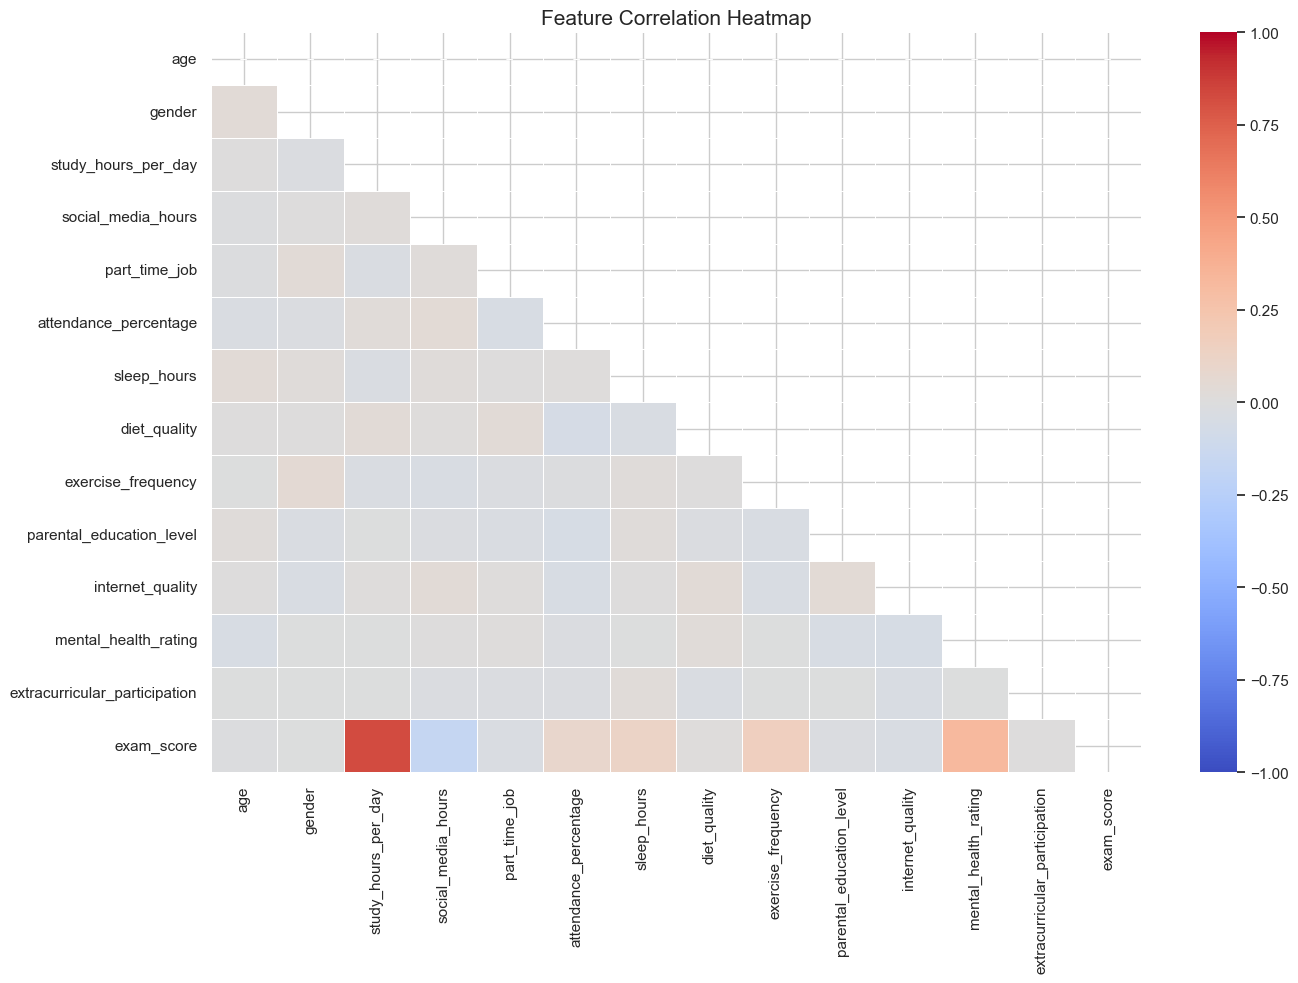


📊 Correlations with exam_score (sorted):
study_hours_per_day              0.825
mental_health_rating             0.322
exercise_frequency               0.160
sleep_hours                      0.122
attendance_percentage            0.090
diet_quality                     0.015
extracurricular_participation    0.001
gender                          -0.002
age                             -0.009
parental_education_level        -0.022
part_time_job                   -0.027
internet_quality                -0.036
social_media_hours              -0.167
Name: exam_score, dtype: float64


In [10]:
corr = df_encoded.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=15)
plt.tight_layout()
plt.savefig('plots/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with exam_score
print('\n📊 Correlations with exam_score (sorted):')
print(corr['exam_score'].drop('exam_score').sort_values(ascending=False).round(3))

## 8. Top Feature Scatter Plots

Top 6 correlated features: ['study_hours_per_day', 'mental_health_rating', 'social_media_hours', 'exercise_frequency', 'sleep_hours', 'attendance_percentage']


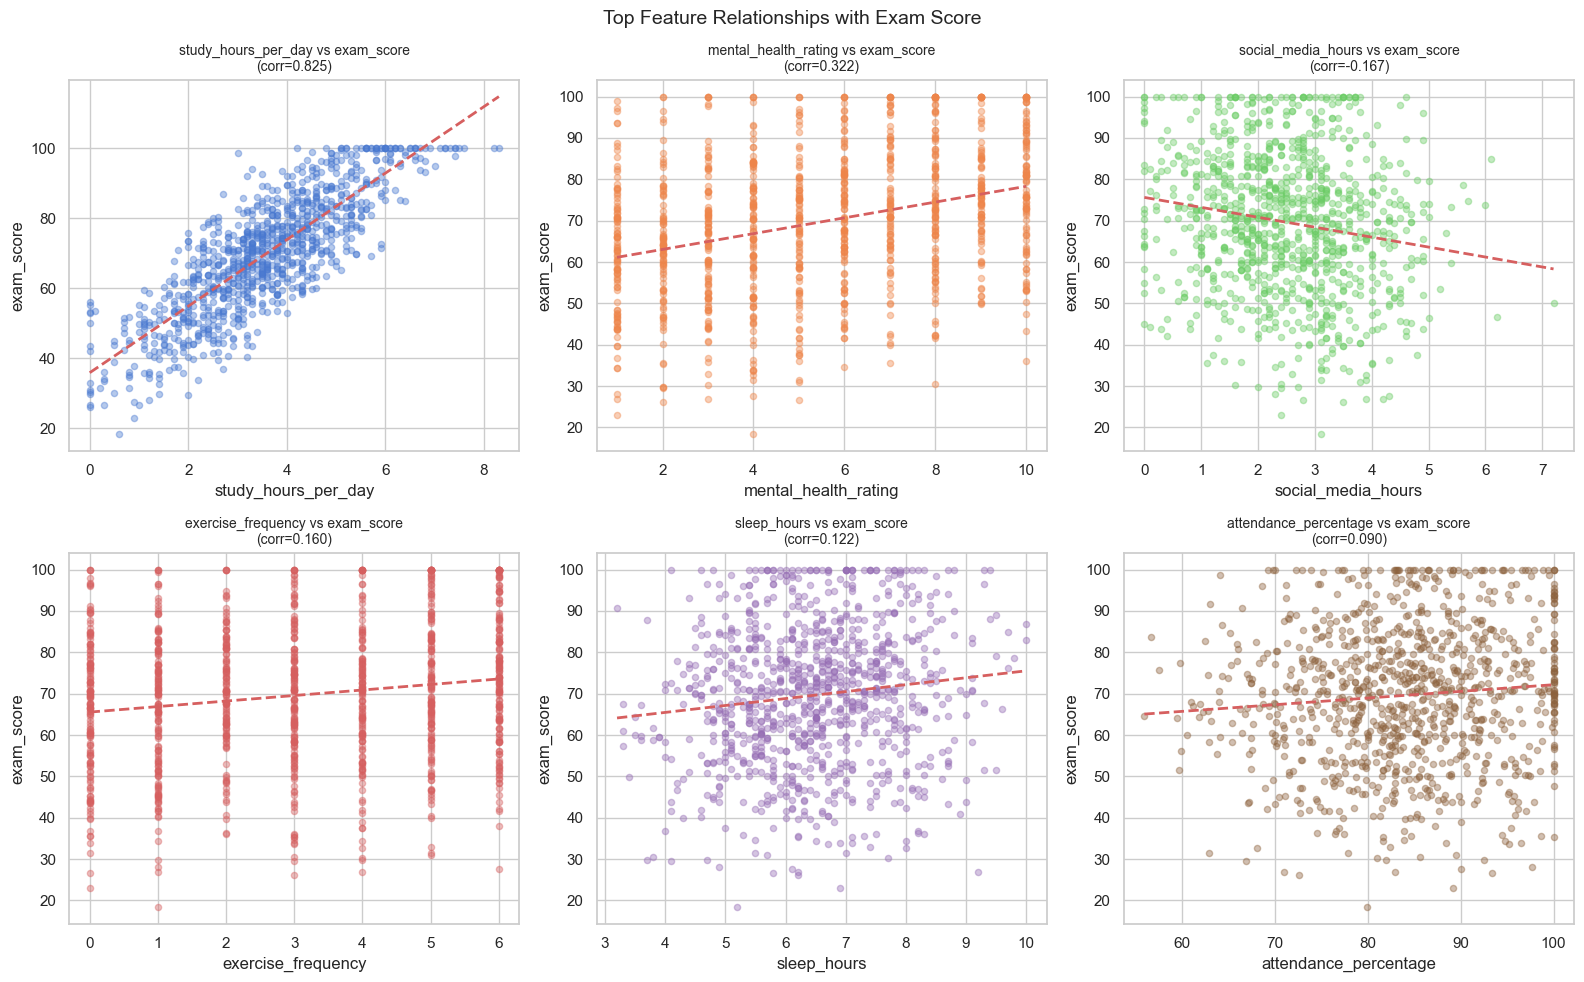

In [11]:
top_features = corr['exam_score'].drop('exam_score').abs().sort_values(ascending=False).head(6).index.tolist()
print('Top 6 correlated features:', top_features)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].scatter(df_encoded[feat], df_encoded['exam_score'],
                    alpha=0.4, color=sns.color_palette('muted')[i], s=20)
    z = np.polyfit(df_encoded[feat], df_encoded['exam_score'], 1)
    p = np.poly1d(z)
    xs = np.linspace(df_encoded[feat].min(), df_encoded[feat].max(), 100)
    axes[i].plot(xs, p(xs), 'r--', linewidth=2)
    axes[i].set_title(f'{feat} vs exam_score\n(corr={corr["exam_score"][feat]:.3f})', fontsize=10)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('exam_score')

plt.suptitle('Top Feature Relationships with Exam Score', fontsize=14)
plt.tight_layout()
plt.savefig('plots/04_top_feature_scatters.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Cleaned Data

In [12]:
df_encoded.to_csv('student_cleaned.csv', index=False)
print(f'✅ Cleaned data saved: student_cleaned.csv')
print(f'Shape: {df_encoded.shape}')
print(f'Features: {[c for c in df_encoded.columns if c != "exam_score"]}')
print(f'Target: exam_score')

✅ Cleaned data saved: student_cleaned.csv
Shape: (1000, 14)
Features: ['age', 'gender', 'study_hours_per_day', 'social_media_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation']
Target: exam_score
